#### [LangChain Handbook](https://www.pinecone.io/learn/series/langchain/)

# Агенты

Агенты — это своего рода «инструменты» для LLM. Они позволяют модели обращаться к поиску Google, выполнять сложные вычисления на Python и даже делать SQL-запросы.

В этой тетрадке мы рассмотрим агентов и то, как использовать их в LangChain.

Начнём с установки необходимых библиотек, которые будем использовать в этом примере.

In [ ]:
!pip install -qU langchain==0.3.25 langchain-openai==0.3.22 langchain-experimental==0.3.4 numexpr==2.11.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.2/209.2 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.4/403.4 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.9/458.9 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.0/363.0 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the so

Подключимся к модели из openrouter.

In [ ]:
OPENROUTER_TOKEN = ""

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    api_key=OPENROUTER_TOKEN,
    base_url="https://openrouter.ai/api/v1",
    model="openrouter/aurora-alpha"
)

response = llm.invoke("Привет! Как твои дела?").content
print(response)

Привет! Всё в порядке, спасибо, что спросил. Как твои дела?


# ВАЖНО! Не любая LLM подойдет: модели с тулзами и без

## Модель **без tools**

- Модель **только генерирует текст** на основе запроса пользователя.  
- Она **не может сама вызвать калькулятор, поиск, SQL-запрос или API**.  
- Всё, что она делает — это рассуждает и пишет текстовый ответ.  
- Пример: обычная GPT-модель без подключения к инструментам.

**Пример:**

- Вопрос: "Сколько будет 12345 * 67?"

- Ответ модели без tools: "Думаю, это около 827115, но я не могу проверить точно."

## Модель **с tools**

- Модель может **вызывать внешние инструменты**, которые мы подключили (tools).  
- Tools могут быть:
  - Калькулятор (`calculator`)
  - Поиск в интернете (`google_search`)
  - Работа с базой данных (`SQL tool`)
  - Любой кастомный API
- Модель решает **сама**, когда вызвать tool, и получает результат обратно.  
- Это делает её способной давать **точные ответы**, а не только текстовые предположения.

**Пример:**

- Вопрос: "Сколько будет 12345 * 67?"

Модель с tools:

- Решает вызвать calculator("12345 * 67")

- Получает результат 827115

- Возвращает финальный ответ пользователю: "Результат: 827115"

# Как строить агентов с помощью LangChain и LangGraph

Если вы хотите создать помощника на базе больших языковых моделей (LLM), вам понадобятся **агенты** — системы, которые могут решать задачи пошагово, использовать инструменты и возвращать точные ответы.  

В мире Python для этого есть два подхода: **LangChain** и **LangGraph**.

---

## 1. LangChain Agents

**LangChain** предлагает готовые шаблоны агентов.  

### Как это работает:

1. **Вы создаёте набор инструментов (tools)**  
   Например:
   - калькулятор (`calculator`)  
   - поиск в интернете (`google_search`)  
   - подключение к базе данных (`SQL tool`)  

2. **Вы выбираете тип агента**  
   Примеры:
   - **ZeroShotAgent** — простой агент, который пытается угадать, какой инструмент использовать.  
   - **ReActAgent** — агент, который умеет рассуждать пошагово (Reason + Act).  
   - **ConversationalReActAgent** — ReAct агент с памятью, который учитывает предыдущие сообщения.  

3. **Агент сам решает, когда и какой инструмент вызвать**  
   Модель получает ваш запрос, анализирует его и вызывает нужный tool.  

### Пример:

> “Посчитай 10000 * (1 + 0.08)**5”

- Агент вызывает калькулятор  
- Получает результат  
- Формирует финальный ответ пользователю  

### Особенности LangChain Agents:

- Простая настройка — подключили инструменты и промпт, агент готов к работе.  
- Подходит для быстрых прототипов.  
- Модель сама управляет логикой, что иногда делает её поведение непредсказуемым.  

---

## 2. LangGraph Agents

**LangGraph** — это подход, при котором вы **строите агента сами** как граф состояний.  

### Как это работает:

1. **Вы создаёте узлы (nodes)**  
   Каждый узел выполняет конкретное действие:
   - вызвать инструмент  
   - обработать текст  
   - проверить результат  

2. **Вы создаёте связи между узлами (edges)**  
   Определяете, что произойдет после выполнения каждого узла.  

3. **Модель участвует только в узлах**  
   LLM может выполнять вычисления или давать рекомендации, но **не управляет потоком**.  

4. **Плюс**: можно добавлять проверку ошибок, память, ретраи, условные переходы и сохранять состояние.  

### Пример:

Для той же задачи “Посчитай 10000 * (1 + 0.08)**5” можно построить граф:
[User Input] → [Calculator Node] → [Validator Node] → [Final Answer Node]




- Каждый узел выполняет строго определённую роль  
- Можно добавлять другие шаги, например, перевод результата в евро или сохранение в базу данных  

### Особенности LangGraph:

- Полный контроль над логикой агента  
- Высокая предсказуемость и надёжность  
- Подходит для сложных систем и продакшн  
- Можно создавать многошаговые, многоагентные воркфлоу  

---

## В чём разница между LangChain и LangGraph

| Характеристика | LangChain Agents | LangGraph Agents |
|----------------|-----------------|-----------------|
| Кто управляет логикой | Модель (LLM) | Разработчик |
| Гибкость | Ограничена | Абсолютная |
| Сложность | Простые / средние задачи | Сложные воркфлоу |
| Предсказуемость | Низкая | Высокая |
| Память | Минимальная | Любая, структурированная |
| Подходит для продакшена | Иногда | Да |

---

## Вывод

- **LangChain Agents** — быстрый способ собрать помощника: подключаем инструменты, выбираем тип агента, LLM сама решает, что делать.  
- **LangGraph Agents** — контроль над каждым шагом: вы строите граф действий, LLM участвует только в отдельных узлах, что делает систему предсказуемой и надёжной.  

**Итоговое правило:**  
LangChain = “готовые блоки, которые магически вызывают инструменты”  
LangGraph = “строим агента сами, LLM помогает на узлах, а логика полностью под нашим контролем”

# 1. Агенты в LangChain

Использование одного из встроенных агентов LangChain включает три переменные:

- Определение инструментов или набора инструментов;

- Определение LLM;

- Определение типа агента.

Всё это очень легко сделать в LangChain, как мы увидим в следующем примере.

# Агент 1: калькулятор

Создадим простого агента, который умеет считать.

Будем использовать math tool:

- `tool` — это декоратор из LangChain, который превращает обычную Python-функцию в инструмент для LLM.

- `numexpr` — библиотека для быстрого и безопасного вычисления математических выражений.

- `math` — стандартная библиотека Python.

In [ ]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables.base import RunnableSerializable
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
from langchain_core.tools import tool

import numexpr
import math

# ----------------------------
# Создаем инструмент-калькулятор
# ----------------------------
@tool
def calculator(expression: str) -> str:
    """
    Вычисляет математическое выражение с помощью numexpr.
    """
    local_dict = {"pi": math.pi, "e": math.e}
    return str(
        numexpr.evaluate(
            expression.strip(),
            global_dict={},  # без глобальных переменных
            local_dict=local_dict
        )
    )

tools = [calculator]

# ----------------------------
# Создаем промпт для агента
# ----------------------------
agent_prompt = ChatPromptTemplate.from_messages([
    ("system", (
        "Ты — помощник-калькулятор. "
        "Принимаешь математические выражения и используешь инструмент calculator для вычислений."
    )),
    ("human", "{input}"),
    ("assistant", "Используй инструмент calculator для вычисления."),
])

## RunnableSerializable

RunnableSerializable - это интерфейс LangChain, который позволяет создавать цепочку действий (pipeline), которую можно вызывать как одну функцию.

У каждой стадии pipeline есть вход (input) и выход (output), и они могут передаваться между стадиями.

In [ ]:
# ----------------------------
# Определяем агента
# ----------------------------

agent: RunnableSerializable = agent_prompt | llm.bind_tools(tools, tool_choice="auto")

In [ ]:
# ----------------------------
# Простая обёртка для вызова агента
# ----------------------------
class SimpleCalculatorAgent:
    def __init__(self):
        self.agent = agent  # агент без памяти

    def invoke(self, expression: str) -> str:
        tool_call = self.agent.invoke({"input": expression})

        # Если агент вызвал calculator, берем результат
        if tool_call.tool_calls:
            tool_call_obj = tool_call.tool_calls[0]
            tool_name = tool_call_obj["name"]
            tool_args = tool_call_obj["args"]

            result = tools[0].invoke(tool_args)
            return result
        else:
            return tool_call.content

# ----------------------------
# Тестируем
# ----------------------------
calc_agent = SimpleCalculatorAgent()

result = calc_agent.invoke("10000 * (1 + 0.08)**5")
print(f"Результат: {result}")

Результат: 14693.280768000006


In [ ]:
calc_agent.invoke("Привет! Я хочу открыть вклад на пять лет под 8% годовых, положить на счет 10 тысяч рублей. Сколько денег будет у меня на счете через 5 лет?")

'14693.280768000006'

In [ ]:
calc_agent.invoke("Привет! Я хочу открыть вклад на пять лет под 8% годовых, положить на счет 10 тысяч рублей. Сколько денег будет у меня на счете через 5 лет? Не используй инструмент calculator для вычислений, а сгенерируй ответ самостоятельно.")

'14693.280768000006'

Пообщаемся с агентом

In [ ]:
calc_agent.invoke("Привет! Как твои дела?")

'Привет! Я готов помочь с вычислениями. Пожалуйста, введите математическое выражение, которое хотите вычислить.'

In [ ]:
calc_agent.invoke("Не подскажешь сколько будет 2 + 3?")

'5'

In [ ]:
calc_agent.invoke("А если результат умножить на 10?")

'Чтобы умножить\u202fна\u202f10\u202fнужен исходный результат. Пожалуйста, укажите число (или выражение), которое нужно умножить на\u202f10.'

##Conversational React-агент

Что, если нам нужен помощник, который запоминает то, о чём мы говорили, умеет рассуждать об этом и использовать инструменты? Для этого существует conversational ReAct-агент.

# Агент 2: калькулятор с памятью


Создадим кастомного агента LangChain, который:

✔️ умеет вызывать инструменты (calculator, final_answer)

✔️ ведёт собственную память разговора (историю)

✔️ анализирует, какие вычисления уже были сделаны ранее

✔️ умеет многократно выполнять итерации ReAct (reasoning + tool use)

✔️ завершает ответ только через инструмент final_answer

✔️ исключает вызовы инструментов из памяти, чтобы её не загрязнять

In [ ]:
@tool
def calculator(expression: str) -> str:
    """Calculate expression using Python's numexpr library.

    Expression should be a single line mathematical expression
    that solves the problem.

    Examples:
        "37593 * 67" for "37593 times 67"
        "37593**(1/5)" for "37593^(1/5)"
        "10000 * (1 + 0.08)**5" for compound interest
    """
    local_dict = {"pi": math.pi, "e": math.e}
    return str(
        numexpr.evaluate(
            expression.strip(),
            global_dict={},  # restrict access to globals
            local_dict=local_dict,  # add common mathematical functions
        )
    )

tools = [calculator]

Тип памяти, который используется здесь, — это простая буферная память, позволяющая нам запоминать предыдущие шаги в цепочке рассуждений.

In [ ]:
from langchain.memory import ConversationBufferMemory

memory = ConversationBufferMemory(
    memory_key="chat_history",
    return_messages=True
)

/tmp/ipython-input-4074810399.py:3: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  memory = ConversationBufferMemory(


In [ ]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables.base import RunnableSerializable
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
from langchain_core.tools import tool

# Add a final_answer tool as recommended in the guide
@tool
def final_answer(answer: str, tools_used: list[str]) -> str:
    """Use this tool to provide a final answer to the user.
    The answer should be in natural language as this will be provided
    to the user directly. The tools_used must include a list of tool
    names that were used within the `scratchpad`.
    """
    return {"answer": answer, "tools_used": tools_used}

# Add tools
tools = [final_answer, calculator]

# First, create a prompt that forces the LLM to analyze the history
history_analysis_prompt = ChatPromptTemplate.from_messages([
    ("system", (
        "Analyze the conversation history below and identify any calculations that have already been performed. "
        "Extract the results of these calculations so they can be reused instead of recalculating."
    )),
    MessagesPlaceholder(variable_name="chat_history"),
    ("human", "What calculations have been done and what are their results?"),
])

# Then the main agent prompt
agent_prompt = ChatPromptTemplate.from_messages([
    ("system", (
        "You're a helpful assistant. When answering a user's question "
        "you should first use one of the tools provided. After using a "
        "tool the tool output will be provided in the "
        "'scratchpad' below. If you have an answer in the "
        "scratchpad you should not use any more tools and "
        "instead answer directly to the user. "
        "IMPORTANT: Use the analysis of previous calculations to avoid recalculating."
    )),
    ("human", "Previous calculations analysis: {history_analysis}"),
    ("human", "{input}"),
    MessagesPlaceholder(variable_name="agent_scratchpad"),
])

## RunnableSerializable - 2

У каждой стадии pipeline есть вход (input) и выход (output), и они могут передаваться между стадиями.

RunnableSerializable собирает всё в единую цепочку, которая:

- Получает входные данные и scratchpad

- Генерирует анализ истории вычислений

- Формирует основной промпт агента, учитывая scratchpad и историю

- Подключает инструменты, которые агент может вызывать

In [ ]:
# define the agent runnable with history analysis first
agent: RunnableSerializable = (
    {
        "input": lambda x: x["input"],
        "chat_history": lambda x: x["chat_history"],
        "agent_scratchpad": lambda x: x.get("agent_scratchpad", [])
    }
    | {
        "history_analysis": lambda x: llm.invoke(history_analysis_prompt.format_messages(
            chat_history=x["chat_history"]
        )).content,
        "input": lambda x: x["input"],
        "agent_scratchpad": lambda x: x.get("agent_scratchpad", [])
    }
    | agent_prompt
    | llm.bind_tools(tools, tool_choice="auto")
)

**Scratchpad** — это место, куда агент записывает всё, что он делает по шагам.

Обычно содержит:

- Промежуточные рассуждения агента (Reason)

- Вызовы инструментов (Act)

- Результаты инструментов (Observation)

Позволяет:

- Не терять данные между шагами

- Не повторять вычисления, которые уже были сделаны

- Держать историю рассуждений внутри одного запроса

Создадим класс-обёртку, который управляет циклом работы агента.

In [ ]:
# create tool name to function mapping as per guide
name2tool = {tool.name: tool.func for tool in tools}

class CustomAgentExecutor:
    def __init__(self, max_iterations: int = 5):
        self.max_iterations = max_iterations
        self.chat_history = []  # Simple list to store conversation history
        self.agent = agent

    def invoke(self, input: str) -> dict:
        # Метод запускает агента на конкретный запрос пользователя
        count = 0
        agent_scratchpad = []

        # Агент работает пошагово до тех пор, пока не найдет финальный ответ или не достигнет лимита итераций.
        while count < self.max_iterations:
            # Вызываем агента для генерации tool call
            # Агент решает, какой инструмент использовать и с какими аргументами.
            # Результат (tool_call) может содержать список tool_calls.
            tool_call = self.agent.invoke({
                "input": input,
                "chat_history": self.chat_history,
                "agent_scratchpad": agent_scratchpad
            })

            # add initial tool call to scratchpad
            agent_scratchpad.append(tool_call)

            # Обрабатываем все tool calls
            # Извлекаем имя инструмента и аргументы.
            # Находим функцию инструмента через name2tool.
            # Выполняем инструмент и получаем результат (tool_out).
            if tool_call.tool_calls:
                for tool_call_obj in tool_call.tool_calls:
                    tool_name = tool_call_obj["name"]
                    tool_args = tool_call_obj["args"]
                    tool_call_id = tool_call_obj["id"]

                    # execute the tool
                    tool_out = name2tool[tool_name](**tool_args)

                    # add the tool output to the agent scratchpad
                    tool_exec = ToolMessage(
                        content=f"{tool_out}",
                        tool_call_id=tool_call_id
                    )
                    agent_scratchpad.append(tool_exec)

                    # add a print so we can see intermediate steps
                    print(f"{count}: {tool_name}({tool_args}) -> {tool_out}")

                count += 1

                # Check if any tool call is the final answer tool
                if any(tc["name"] == "final_answer" for tc in tool_call.tool_calls):
                    # Get the final answer from the final_answer tool
                    final_tool_call = next(tc for tc in tool_call.tool_calls if tc["name"] == "final_answer")
                    final_answer = final_tool_call["args"]["answer"]
                    break
            else:
                # no tool call, we have a final answer
                final_answer = tool_call.content
                break

        # Add to conversation history ONLY the human input and final AI response
        # This preserves memory without corrupting it with tool calls
        self.chat_history.extend([
            HumanMessage(content=input),
            AIMessage(content=final_answer)
        ])

        # return the final answer in dict form
        return {"output": final_answer}

# Initialize the custom agent executor
conversational_agent = CustomAgentExecutor()

In [ ]:
# First question
# result = conversational_agent.invoke("Я взяла кредит на 20 лет под 10 процентов годовых. Кредит на сумму 100000 рублей. Какая у меня будет переплата через 20 лет?")

result = conversational_agent.invoke("What is 10000 * (1 + 0.08)**5?")
print(f"Result: {result['output']}")

0: calculator({'expression': '10000 * (1 + 0.08)**5'}) -> 14693.280768000006
1: final_answer({'answer': 'The result is approximately 14,693.28.', 'tools_used': ['calculator']}) -> {'answer': 'The result is approximately 14,693.28.', 'tools_used': ['calculator']}
Result: The result is approximately 14,693.28.


Визуализируем внутренность агента:

In [ ]:
print("Prompt Template Structure:")
print("=" * 50)
print("System message:", agent_prompt.messages[0].prompt.template)
print("History analysis template:", agent_prompt.messages[1].prompt.template)  # Show the memory component
print("Human message template:", agent_prompt.messages[2].prompt.template)
print("Variables:", agent_prompt.input_variables)
print("=" * 50)

Prompt Template Structure:
System message: You're a helpful assistant. When answering a user's question you should first use one of the tools provided. After using a tool the tool output will be provided in the 'scratchpad' below. If you have an answer in the scratchpad you should not use any more tools and instead answer directly to the user. IMPORTANT: Use the analysis of previous calculations to avoid recalculating.
History analysis template: Previous calculations analysis: {history_analysis}
Human message template: {input}
Variables: ['agent_scratchpad', 'history_analysis', 'input']


Давайте посмотрим, что произойдет, если мы теперь зададим уточняющий вопрос.

In [ ]:
result = conversational_agent.invoke(
    "If we start with $15,000 instead and follow the same 8% annual growth for 5 years with compound interest, how much more would we have compared to the previous scenario?"
)
print(f"Result: {result['output']}")

0: calculator({'expression': '15000 * (1.08) ** 5'}) -> 22039.92115200001
1: calculator({'expression': '15000 * (1.08) ** 5 - 10000 * (1.08) ** 5'}) -> 7346.640384000004
2: final_answer({'answer': 'Starting with $15,000 and applying 8% annual compound growth for 5 years would give about $22,039.92. Compared to the $10,000 starting amount, which grew to about $14,693.28, you would have roughly $7,346.64 more.', 'tools_used': ['calculator']}) -> {'answer': 'Starting with $15,000 and applying 8% annual compound growth for 5 years would give about $22,039.92. Compared to the $10,000 starting amount, which grew to about $14,693.28, you would have roughly $7,346.64 more.', 'tools_used': ['calculator']}
Result: Starting with $15,000 and applying 8% annual compound growth for 5 years would give about $22,039.92. Compared to the $10,000 starting amount, which grew to about $14,693.28, you would have roughly $7,346.64 more.


In [ ]:
result = conversational_agent.invoke(
    "If we start with $15,000 instead and follow the same 8% annual growth for 5 years with compound interest, how much more would we have compared to the previous scenario?"
)
print(f"Result: {result['output']}")

0: final_answer({'answer': 'With a $15,000 starting principal growing at 8% annually for 5 years, you’d end up with $22,039.92. Compared to the $10,000 scenario ($14,693.28), that’s an additional $7,346.64.', 'tools_used': []}) -> {'answer': 'With a $15,000 starting principal growing at 8% annually for 5 years, you’d end up with $22,039.92. Compared to the $10,000 scenario ($14,693.28), that’s an additional $7,346.64.', 'tools_used': []}
Result: With a $15,000 starting principal growing at 8% annually for 5 years, you’d end up with $22,039.92. Compared to the $10,000 scenario ($14,693.28), that’s an additional $7,346.64.


# 2. Агенты на LangGraph

# Агент 3: умный хаббл-детектор
Задача агента - проста. Говорить над какой страной или над каким материком находится сейчас телескоп Хаббл


Он будет работать в 3 шага:
- 1 - понимать, что нужно: страна или материк
- 2 - получать текущие координаты Хаббла
- 3 - Говорить над чем находится Хаббл


Сначала зададим архитектуру кратковременной памяти/state, через который мы будем передавать данные между шагами

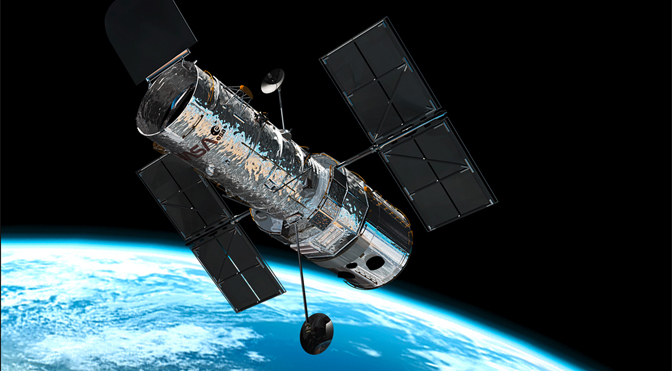

## LangGraph

Для создания агентов мы будем пользоваться фреймворком LangGraph - он позволит нам реализовывать AI-агентов в виде графа из различных состояний.

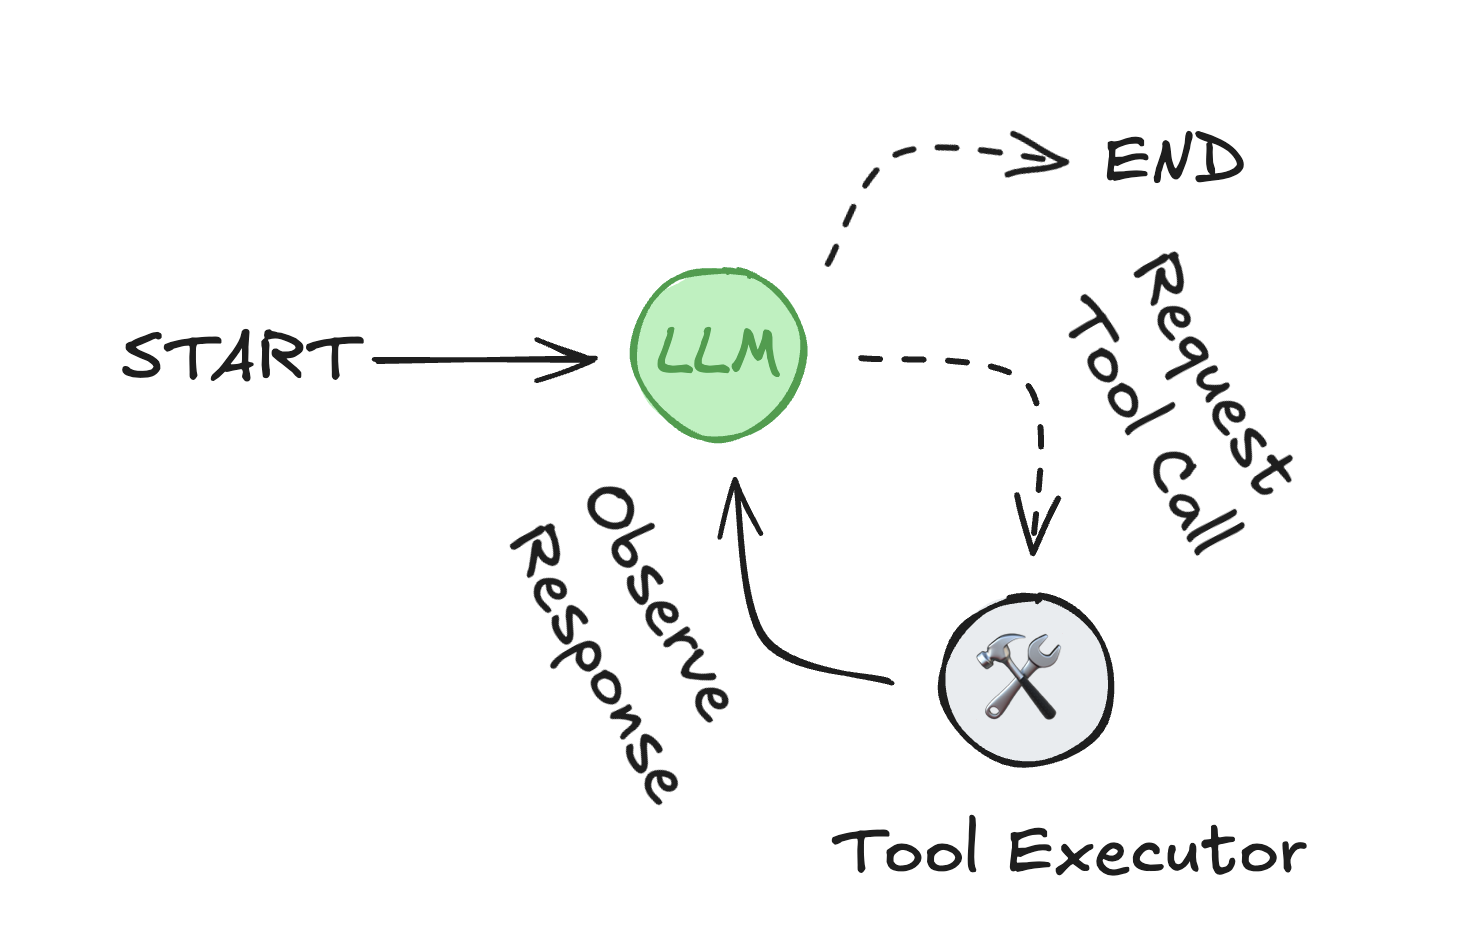

In [ ]:
!pip install langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 500.5/500.5 kB 13.7 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.83
    Uninstalling langchain-core-0.3.83:
      Successfully uninstalled langchain-core-0.3.83
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 0.3.25 requires langchain-core<1.0.0,>=0.3.58, but you have langchain-core 1.2.13 which is incompatible.
langchain-openai 0.3.22 requires langchain-core<1.0.0,>=0.3.64, but you have langchain-core 1.2.13 which is incompatible.
langchain-experimental 0.3.4 requires langchain-core<0.4.0,>=0.3.28, but you have langchain-core 1.2.13 which is incompatible.
langchain-community 0.3.25 requires langchain-core<1.0.0,>=0.3.65, but you have langchain-core 1.2.13 which is incompatible.


In [ ]:
from typing import TypedDict, List
from langgraph.graph import START, END, StateGraph

class Coordinates(TypedDict):
    lat: float
    long: float

# Define a complete State class with all fields
class HubbleState(TypedDict):
    question: str
    question_kind: int
    coordinates: Coordinates
    latitude: float
    longitude: float
    answer: str

Сначала по запросу пользователя определим тип вопроса, который он задает: страна или океан/материк. Решим эту задачу с помощью LLM.

In [ ]:
def get_question_type(state: HubbleState):
    prompt = f"""
# Инструкция
Перед тобой вопрос пользователя к агенту. Тебе нужно классифицировать вопрос на два класса (дополнительный класс 0 - некорректный запрос).
Если вопрос касается страны, над которой находится Hubble - верни 1,
если касается материка или океана - верни 2,
если прочего - верни 0.
Напиши только одно число, не пиши никаких коментариев. Не размышляй
# Примеры
Пример 1
Вопрос: Над какой страной пролетает Hubble?
Ответ: 1
------
Пример 2
Вопрос: Над каким океаном пролетает Hubble?
Ответ: 2
------
Пример 2
Вопрос: Сколько космонавтов на Hubble?
Ответ: 0
------
# Вопрос пользователя, который нужно классифицировать
{state['question']}
    """

    result = llm.invoke(prompt).content

    print("get_question_type result:", result)
    try:
        question_kind = int(result)
    except:
        question_kind = 0

    print("State after get_question_type:", {"question": state.get('question'), "question_kind": question_kind})
    return {"question_kind": question_kind}

Теперь получим координаты Хаббла - по API!

In [ ]:
import requests

def get_hubble_location(state: HubbleState):
    """
    Получает текущие координаты космического телескопа Hubble (NORAD ID 20580)
    через API N2YO и сохраняет их в state["coordinates"].

    Параметры:
        state (dict): текущее состояние агента
        api_key (str): ваш API ключ для https://www.n2yo.com/api/

    Возвращает:
        dict: обновлённое состояние с координатами
    """
    print("State entering get_hubble_location:", state)

    # NORAD ID телескопа Hubble
    hubble_id = 20580

    # Позиция наблюдателя не влияет на результат (можно поставить 0,0)
    observer_lat, observer_lng, observer_alt = 0, 0, 0

    # Формируем запрос
    url = (
        f"https://api.n2yo.com/rest/v1/satellite/positions/"
        f"{hubble_id}/{observer_lat}/{observer_lng}/{observer_alt}/1/&apiKey=..." # your api key
    )

    response = requests.get(url)
    response.raise_for_status()
    data = response.json()

    # Проверка и извлечение координат
    if "positions" not in data or not data["positions"]:
        raise ValueError("Не удалось получить данные о координатах Hubble.")

    position = data["positions"][0]
    latitude = position["satlatitude"]
    longitude = position["satlongitude"]

    print("Hubble coordinates:", latitude, longitude)

    # Обновляем состояние
    state["coordinates"] = {"lat": latitude, "long": longitude}
    return state

Наконец, напишем шаг, который будет по координатам возвращать требуемый ответ

In [ ]:
def get_answer(state: HubbleState):
    print("Full state entering get_answer:", state)

    # Check if coordinates are in the state
    if "coordinates" not in state:
        print("ERROR: Missing coordinates in state")
        return {"answer": "Ошибка: Не удалось получить координаты Hubble"}

    lat = state["coordinates"]["lat"]
    long = state["coordinates"]["long"]

    if state["question_kind"] == 1:
        prompt = f"Над какой страной пролетает Hubble, если я запросил координаты над которыми он находится и они равны:({lat},{long})?"
    elif state["question_kind"] == 2:
        prompt = f"Над каким материком или океаном пролетает Hubble, если я запросил координаты над которыми он находится и они равны: ({lat},{long})?"
    else:
        prompt = f"Напиши в ответе: ОШИБКА, ЗАДАЙТЕ КОРРЕКТНЫЙ ЗАПРОС"

    result = llm.invoke(prompt).content
    print("get_answer result:", result)
    return {"answer": result}

А теперь соберем весь граф размышлений. Сначала создадим вершины, потом соединим их ребрами.

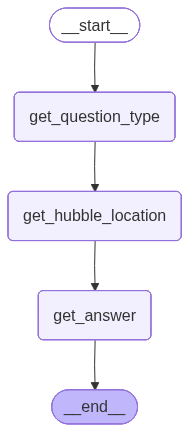

In [ ]:
graph_builder = StateGraph(HubbleState)

graph_builder.add_node("get_question_type", get_question_type)
graph_builder.add_node("get_hubble_location", get_hubble_location)
graph_builder.add_node("get_answer", get_answer)

graph_builder.add_edge(START, "get_question_type")
graph_builder.add_edge("get_question_type", "get_hubble_location")
graph_builder.add_edge("get_hubble_location", "get_answer")
graph_builder.add_edge("get_answer", END)

graph = graph_builder.compile()
graph

Проверим, как работает!

На вход такому агенту нужно подавать State или его кусочек.

In [ ]:
answer1 = graph.invoke({"question":"Над какой страной пролетает Hubble?"})["answer"]
print('---------------')
print(answer1)

get_question_type result: 1
State after get_question_type: {'question': 'Над какой страной пролетает Hubble?', 'question_kind': 1}
State entering get_hubble_location: {'question': 'Над какой страной пролетает Hubble?', 'question_kind': 1}
Hubble coordinates: -19.45988227 97.23668825
Full state entering get_answer: {'question': 'Над какой страной пролетает Hubble?', 'question_kind': 1, 'coordinates': {'lat': -19.45988227, 'long': 97.23668825}}
get_answer result: Координаты (-19.45988227 °, 97.23668825 °) находятся в южном полушарии, в центре Индийского океана.  

- Широта ≈ ‑19° С – это примерно на уровне южных широт, где океан простирается от Африки к Австралии.  
- Долгота ≈ 97° В – это находится ближе к центру океана, между восточным побережьем Африки (Мадагаскар находится около 45° Е) и западным побережьем Австралии (К запережье Австралии начинается примерно с 115° Е).  

Таким образом, над этими координатами **не пролетается ни одна страна** – это открытый океан. Ближе всего к точк

In [ ]:
answer2 = graph.invoke({"question":"Над каким океаном пролетает Hubble?"})["answer"]
print('---------------')
print(answer2)

get_question_type result: 2
State after get_question_type: {'question': 'Над каким океаном пролетает Hubble?', 'question_kind': 2}
State entering get_hubble_location: {'question': 'Над каким океаном пролетает Hubble?', 'question_kind': 2}
Hubble coordinates: -21.46113991 102.59877445
Full state entering get_answer: {'question': 'Над каким океаном пролетает Hubble?', 'question_kind': 2, 'coordinates': {'lat': -21.46113991, 'long': 102.59877445}}
get_answer result: Координаты (-21.46113991 ° S, 102.59877445 ° E) — это точка, находящаяся **в Индийском океане**, недалеко от западного побережья Австралии (между континентом и островом Рождества).  

Hubble Space Telescope находится на орбите около 540 км над поверхностью Земли, поэтому «над» этими координатами он просто проходит над соответствующей точкой океана, а не над сушей.
---------------
Координаты (-21.46113991 ° S, 102.59877445 ° E) — это точка, находящаяся **в Индийском океане**, недалеко от западного побережья Австралии (между кон

In [ ]:
answer3 = graph.invoke({"question":"Cколько лет прожил Лев Толстой?"})["answer"]
print('---------------')
print(answer3)

get_question_type result: 0
State after get_question_type: {'question': 'Cколько лет прожил Лев Толстой?', 'question_kind': 0}
State entering get_hubble_location: {'question': 'Cколько лет прожил Лев Толстой?', 'question_kind': 0}
Hubble coordinates: -22.28724494 105.02981403
Full state entering get_answer: {'question': 'Cколько лет прожил Лев Толстой?', 'question_kind': 0, 'coordinates': {'lat': -22.28724494, 'long': 105.02981403}}
get_answer result: ОШИБКА, ЗАДАЙТЕ КОРРЕКТНЫЙ ЗАПРОС
---------------
ОШИБКА, ЗАДАЙТЕ КОРРЕКТНЫЙ ЗАПРОС


# Домашнее задание 1

В рамках первого домашнего задания курса предлагаем Вам реализовать двух агентов:

1. ReAct-агент на LangChain - пусть он использует какие-нибудь тулзы, имеет память и решает полезную для вас микро-задачу.

2. Агент на LangGraph - пусть он обращается к какому-нибудь открытому API по вашему запросу, анализирует ответ от API и выдает пропущенные через LLM результат. Тут надо поискать открытые API и подумать, какую полезную микро-задачу будет решать агент.

Домашнее задание оформите в виде jupyter-notebook. Перед кодом для каждого агента текстом подробно опишите, для чего нужен агент, как он работает и какую задачу решает.

Удачи!